## data loading

In [1]:
import sys
import os


sys.path.append('..')
os.chdir('..')

In [ ]:
# dataset
import os
import torch

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset


torch.set_printoptions(profile="full")

DATA_DIR = os.getenv('DATA_DIR')

config = Configuration.create('./configs/paraff-visionund-data.yaml', volatile=True)
data, = loadDataset(config, data_dir=DATA_DIR, splits='*0/1')

it = iter(data)
batch = next(it)
batch

/home/camus/work/deep-starry/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.


In [ ]:
batch['input_ids'].shape, batch['target_mask'].shape, batch['img_emb'].shape, batch['image_seq_mask'].shape

(torch.Size([2, 765]),
 torch.Size([2, 765]),
 torch.Size([2, 1, 576, 1024]),
 torch.Size([2, 765]))

In [ ]:
print(data.dataset.tokenizer.decode(batch['input_ids'][0]))

<｜begin▁of▁sentence｜>You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.

<|User|>: <begin_of_image><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><image_placeholder><imag

---
## model

In [1]:
import sys
import os


sys.path.append('..')
os.chdir('..')

In [ ]:
# dataset
import os
import torch

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel


torch.set_printoptions(profile="full")

DATA_DIR = os.getenv('DATA_DIR')

config = Configuration.create('./configs/paraff-visionund-test.yaml', volatile=True)
train, = loadDataset(config, data_dir=DATA_DIR, splits='*0/1', device='cuda')
model = loadModel(config['model'], postfix='Loss').cuda()

it = iter(train)

#batch = next(it)
#loss, metric = model(batch)
#
#loss, metric

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
2025-03-26 15:23:37.355591: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-26 15:23:37.355632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-26 15:23:37

(tensor(11.8125, device='cuda:0', dtype=torch.bfloat16,
        grad_fn=<NllLossBackward0>),
 {'loss': 11.8125, 'acc': 0.0})

In [11]:
batch = next(it)
loss, metric = model(batch)

loss, metric

(tensor(12.1875, device='cuda:0', dtype=torch.bfloat16,
        grad_fn=<NllLossBackward0>),
 {'loss': 12.1875, 'acc': 0.0})

In [3]:
emb = model.deducer.janus.get_input_embeddings()
emb

Embedding(102400, 4096)

In [29]:
model.deducer.state_dict().keys()

odict_keys(['add_embedding', 'lm_head.weight'])

In [4]:
model.deducer.janus.config.hidden_size

4096

In [5]:
from starry.utils.trainer import print_metric


print_metric(metric)

'loss: 11.8125, acc: 0.0000'

In [6]:
list(map(lambda item: f'{item[0]}: {item[1]:.4f}',
			filter(lambda item: type(item[1]) in [int, float],
				metric.items())))

['loss: 11.8125', 'acc: 0.0000']

In [8]:
model.deducer.add_embedding.grad

In [12]:
loss.backward()

In [13]:
model.deducer.add_embedding.grad.abs().sum()

tensor(1264., device='cuda:0', dtype=torch.bfloat16)

In [14]:
model.eval()


with torch.no_grad():
	inspection = model.inspectRun(batch)

inspection['target_flat'].shape, inspection['pred_flat'].shape

(torch.Size([198]), torch.Size([198, 102400]))

In [15]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(config['data.args.tokenizer.path'])
tokenizer

LlamaTokenizerFast(name_or_path='/home/camus/data/models/Janus-Pro-7B-language', vocab_size=100000, model_max_length=16384, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<｜begin▁of▁sentence｜>', 'eos_token': '<｜end▁of▁sentence｜>'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	38: AddedToken("G", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	54: AddedToken("W", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	64: AddedToken("a", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	65: AddedToken("b", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	66: AddedToken("c", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	67: AddedToken("d", rstrip=False, lstrip=False, single_word=True, normalized=False, special=False),
	68: AddedToken("e", rstrip=False, lstrip=False, single_wo

In [16]:
batch['input_ids']

tensor([[100000,   2054,    418,    207,     64,   9394,   4706,    285,  10046,
          20308,     13,   1257,    418,   2249,    276,   2579,    254,   7959,
           3093,    344,    254,   2677,   4614,     11,    285,   4750,    254,
           2677,    366,    207,     64,   6265,    280,   9224,   1244,   3892,
           4706,     13,    185,    185, 100601,     25,    207, 100016, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594, 100594,
         100594, 100594, 100

In [17]:
tokenizer.decode(inspection['target_flat'])

'BOM K_4 TN2 TD2 S1 Cg Md a Af Osup Osup W2 D8 Bl EslurL b Af W D8 a Af W D8 Br Md g W2 D8 Bl a Af W D8 e W D8 Br Md f W2 D8 Bl g W D8 f W D8 Br Md e W2 D8 Bl f W D8 d Af W D8 Br VB S2 Cf Md d Af Osub W2 D4 EslurL f Osup W D4 b Af Osub W D4 EslurR Md a Af W2 D4 EslurL f Osup W D4 b Af Osub W D4 EslurR EOM<｜end▁of▁sentence｜>'

In [18]:
for k, v in inspection.items():
	inspection[k] = v.cpu()

inspection['target_flat'] = inspection['target_flat'].tolist()

In [19]:
inspection['pred_flat'].shape

torch.Size([198, 102400])

In [20]:
vocab = []

id_set = set(inspection['target_flat'])
id_list = list(id_set)

for id in id_list:
	vocab.append(tokenizer.decode(id))

# replace value of 'target_flat' with its index in id_list
inspection['target_flat'] = [id_list.index(i) for i in inspection['target_flat']]

# construct a matrix, to map id in inspection['target_flat'] to the index in vocab
mapping = torch.nn.functional.one_hot(torch.tensor(id_list), num_classes=inspection['pred_flat'].shape[-1]).transpose(0, 1).to(model.dtype)

inspection['pred_flat'] = inspection['pred_flat'] @ mapping

vocab

['S2',
 'Cg',
 'K_4',
 'TN2',
 'Br',
 'Md',
 'TD2',
 'Osup',
 'Cf',
 'Osub',
 '<｜end▁of▁sentence｜>',
 'D4',
 'D8',
 'W2',
 'W',
 'EOM',
 'a',
 'Af',
 'b',
 'd',
 'e',
 'f',
 'g',
 'EslurL',
 'EslurR',
 ' ',
 'Bl',
 'BOM',
 'VB',
 'S1']

In [21]:
len(vocab)

30

In [22]:
inspection['pred_flat'].shape

torch.Size([198, 30])

In [23]:
from starry.paraff.viewer import ParaffViewer


viewer = ParaffViewer(dict(_vocab=''))
viewer.vocab = vocab
viewer

In [24]:
import matplotlib


matplotlib.use('module://matplotlib_inline.backend_inline')

In [25]:
%matplotlib inline

/home/camus/work/deep-starry/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


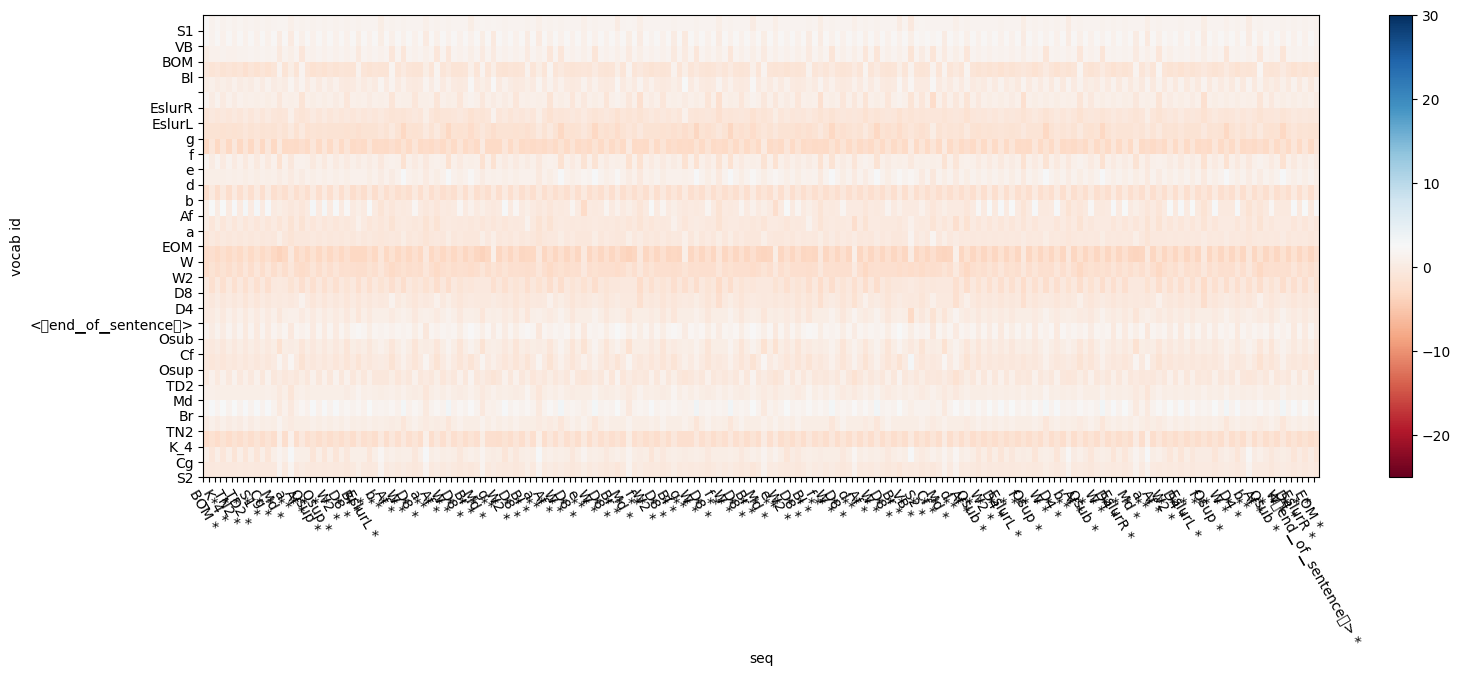

In [26]:
import matplotlib.pyplot as plt


plt.figure(figsize=(18, 6))

viewer.showBatch(None, inspection)

plt.show()

---

In [27]:
print('\n'.join(model.deducer.state_dict().keys()))

add_embedding
lm_head.weight
